In [34]:
import os
import pandas as pd
import wave
import numpy as np
import matplotlib.pyplot as plt
import librosa
import shutil
import pickle
import pywt
from scipy.stats import kurtosis
import wav_utils
from skimage.filters import threshold_otsu
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon

In [3]:
from sklearn.preprocessing import normalize


def create_mel_spectrogram(data, sample_rate, n_mels=128, f_min=50, f_max=1800, winLength = 256, nfft=512, hop=256, show_function=True):
    S = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=n_mels, fmin=f_min, fmax=f_max,
                                       win_length = winLength, n_fft=nfft, hop_length=hop)
    S = librosa.power_to_db(S, ref=np.max)
    S = (S - S.min()) / (S.max() - S.min())

    if show_function:
        fig, ax = plt.subplots()
        fig.set_size_inches(8,3)

        img = librosa.display.specshow(S, x_axis='time',
                                       y_axis='mel', sr=sample_rate, hop_length = hop,
                                       fmax=f_max, ax=ax)
        plt.show()

    return S

def create_MFCC_plot(data, sample_rate, n_mels=128, f_min=50, f_max=1800, winLength = 256, nfft=512, hop=256, numCoeffs = 13,show_function=True):
    mel_spec = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=n_mels, fmin=f_min, fmax=f_max,
                                       win_length = winLength, n_fft=nfft, hop_length=hop)
    
    # Convert to log scale
    log_mel_spec = librosa.power_to_db(mel_spec)

    mfccs = librosa.feature.mfcc(S=log_mel_spec,n_mfcc=numCoeffs,hop_length=hop)

    mfccs_norm = mfccs.copy()

    for row in range(len(mfccs)):
        mfccs_norm[row] =wav_utils.dc_normalise(mfccs[row])
    
    if show_function:
        fig, ax = plt.subplots()
        fig.set_size_inches(8,3)

        img = librosa.display.specshow(mfccs_norm, x_axis='time',
                                       sr=sample_rate, ax=ax,hop_length=hop)
        
        plt.ylabel('MFCC Coefficients')
        plt.title('MFCC')
        plt.tight_layout()
        plt.show()

    return mfccs_norm

In [ ]:
from scipy.signal import butter, filtfilt

def highpass_filter(data, cutoff, fs, order=4):
    nyq = fs / 2
    b, a = butter(order, cutoff / nyq, btype='high')
    return filtfilt(b, a, data)

# Remove everything below 50-80 Hz to isolate wheezes
filtered = highpass_filter(S1_sum, cutoff=80, fs=sample_rate)

plt.plot(filtered[:S1_1s_idx])

filt_norm = wav_utils.dc_normalise(filtered)


In [ ]:
def count_threshold_crossings(signal, threshold):
    """Count how many times signal crosses threshold in either direction"""
    # Create boolean array: True where signal > threshold
    above = signal > threshold
    
    # Find where consecutive values differ (crossing points)
    # This works because True/False convert to 1/0, and diff shows changes
    crossings = np.diff(above.astype(int))
    
    # Count non-zero values (both +1 and -1 are crossings)
    return np.count_nonzero(crossings)

Eko_p002_t01_severe_pos_U_stance_U_20250221.wav
0.224 0.008 816 1008


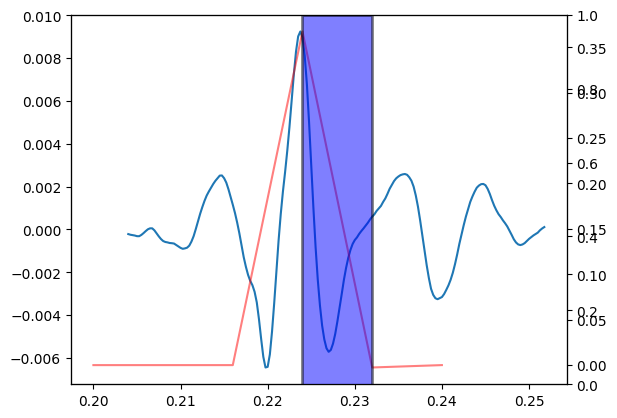

0.264 0.008 976 1168


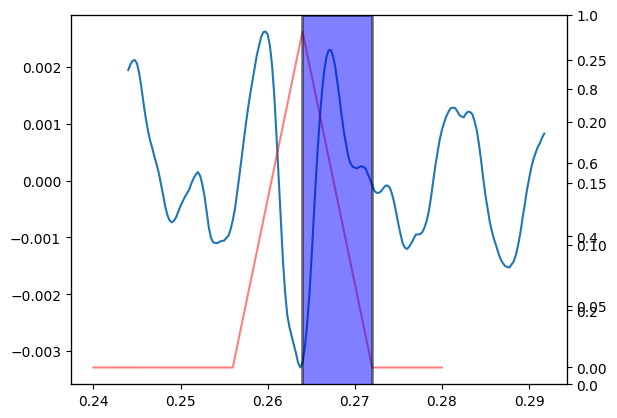

0.336 0.008 1264 1456


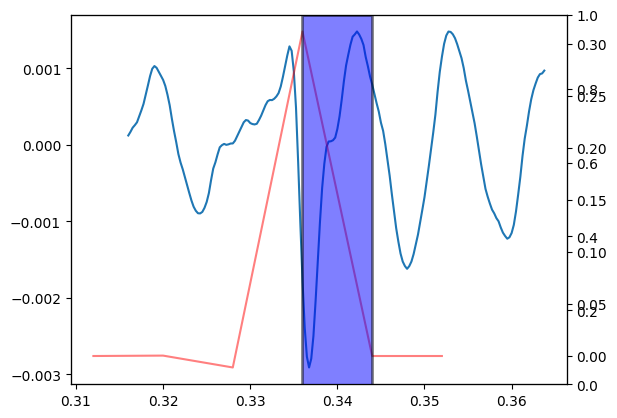

0.88 0.008 3440 3632


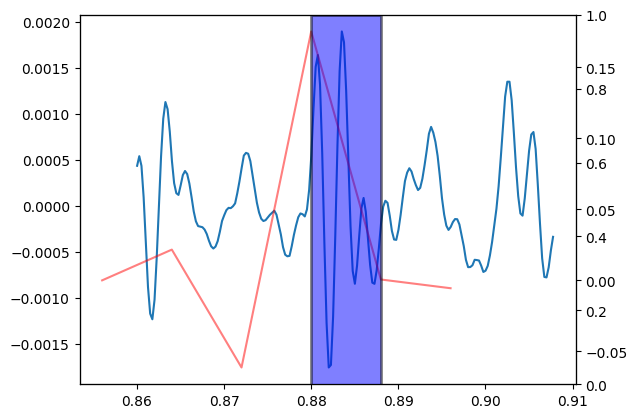

1.08 0.008 4240 4432


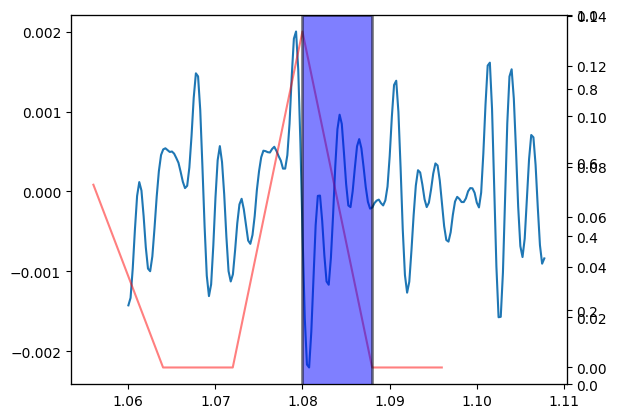

1.76 0.008 6960 7152


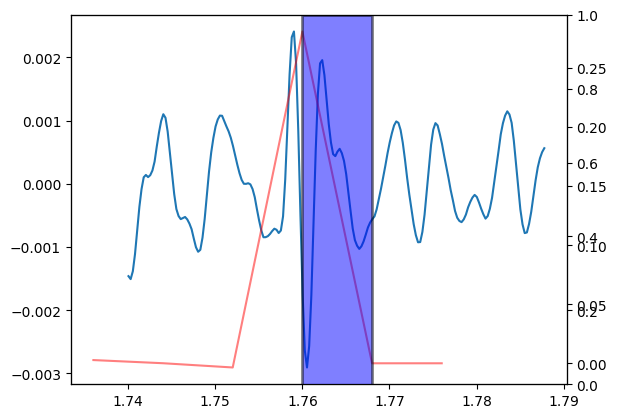

1.856 0.008 7344 7536


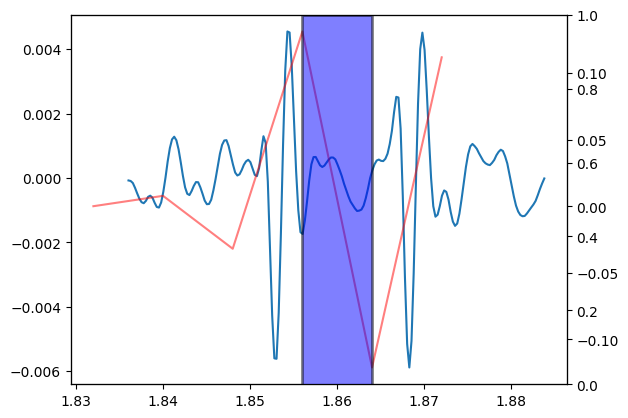

1.872 0.008 7408 7600


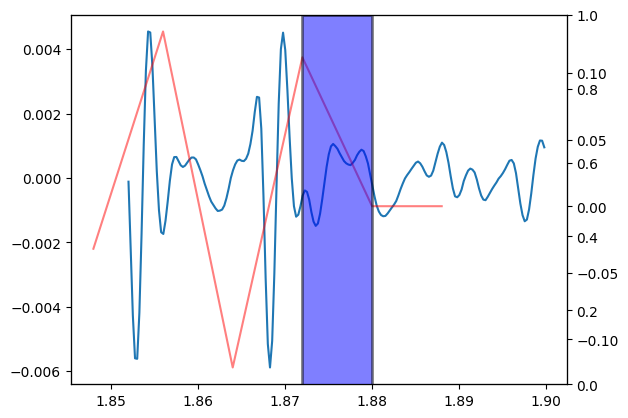

1.944 0.008 7696 7888


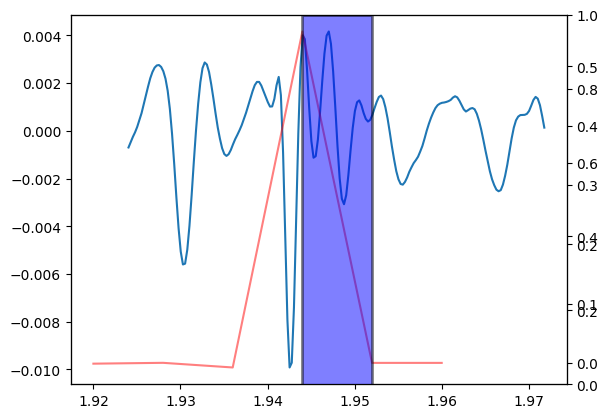

2.088 0.008 8272 8464


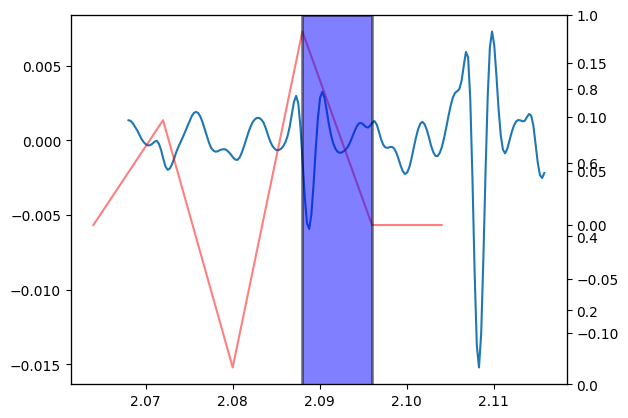

In [84]:
dataFolder = "Samples"

n_fft = 4096 

data_files = os.listdir(dataFolder)
data_files.sort()
#data_files = ['Eko_p000_t01_healthy_pos_U_stance_U_20250228.wav']
data_files = ['Eko_p002_t01_severe_pos_U_stance_U_20250221.wav']

for data_file in data_files:

    #if not a wav file, skip
    if ".wav" not in data_file:
        continue

    print(data_file)

    # path
    wavFilepath = f"{dataFolder}/{data_file}"

    # load data
    raw_audio, sample_rate = librosa.load(path=wavFilepath, sr=4000)

    # Noise reduction method, filter
    filter_lowcut = 80
    filter_highcut = 1800
    filter_order = 8
    filter_btype = "bandpass"  
    filt_audio = wav_utils.filter_denoise(raw_audio, sample_rate, filter_order,
                                    filter_lowcut, filter_highcut, btype=filter_btype)

    # Normalise and remove DC component in signal
    x = wav_utils.dc_normalise(filt_audio)  
    #x = filt_audio.copy()

    # getting mel spectrogram for crackle frequencies (100-800Hz)
    S1 = create_mel_spectrogram(x,sample_rate,winLength=32,nfft = 512,f_min=100,f_max=800,hop=32,show_function=False)
    
    S1_sum = S1.sum(axis=0)

    t_total = len(x) / sample_rate
    t = np.linspace(0,t_total,len(x))
    fs_spectrogram = int(len(S1[0])/t_total)
    S1_10s_idx = int(10/t_total * len(S1_sum))

    S1_sum_norm = wav_utils.filter_denoise(S1_sum, fs_spectrogram, 4, 20, btype='highpass') # removing low-freq drift from  S1_sum_norm to improve TKE performance
    S1_sum_norm = wav_utils.dc_normalise(S1_sum_norm)

    S1_sum_norm = np.array([max(x,0) for x in S1_sum_norm])

    S1_tke = wav_utils.tke(S1_sum_norm,order=1)

    # plt.plot(S1_tke)
    # plt.show()
    
    tke_thresh = 0.1
    above_thresh = S1_tke > tke_thresh

    # Calculating duration that crackle TKE stays above threshold
    S1_crackles = np.zeros_like(above_thresh,dtype=int)
    count = 0
    prevAboveThresh = False
    for i in range(len(above_thresh)):
        if above_thresh[i]:
            if prevAboveThresh:
                count +=1
            else:
                count+=1
                prevAboveThresh = True
        else:
            if prevAboveThresh:
                #record count in location of first value above thresh
                S1_crackles[i-count] = count 
                count = 0
                prevAboveThresh = False
                
    # ensuring last crackle is entered (i.e if signal hasn't dropped below threshold)
    if count != 0:
        S1_crackles[-count] = count

    # plt.plot(S1_crackles,'g')
    # plt.show()

    # getting timestamps of each crackle start

    step = 1/fs_spectrogram
    crackle_ts = np.array([(idx,x,idx*step,x*step) for idx,x in enumerate(S1_crackles) if x>0]) #convert index to timestamp by multiplying be time step between each index
    
    max_num_plots = 10
    plot_buffer = 0.02 # time gap before and after crackle window to plot
    

    for plot_num in range(max_num_plots):
        # create a plot of filt_audio signal starting 0.25s before crackle_ts, with a patch fill for the region covering the duration of the crackle, with 0.25s after
        event_idx,event_duration_points,event_ts, event_duration_s = crackle_ts[plot_num]
        filt_start_index = max(0,int((event_ts - plot_buffer) * sample_rate))
        filt_end_index = min(int((event_ts + event_duration_s + plot_buffer)*sample_rate),len(filt_audio))

        print(event_ts,event_duration_s,filt_start_index,filt_end_index)

        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.plot(t[filt_start_index:filt_end_index],filt_audio[filt_start_index:filt_end_index])
        ax_tke = ax.twinx()
        t_tke = np.linspace(0,t_total,len(S1_tke))
        tke_startIdx = int(event_idx - plot_buffer * fs_spectrogram)
        tke_endIdx = int(event_idx+event_duration_points + plot_buffer * fs_spectrogram)
        ax_tke.plot(t_tke[tke_startIdx:tke_endIdx],S1_tke[tke_startIdx:tke_endIdx],'r',alpha=0.5)
        axPatch = ax.twinx()
        vertices =  [(event_ts, -1), (event_ts+event_duration_s, -1), (event_ts+event_duration_s, 1), (event_ts, 1)]
        poly = Polygon(vertices, 
               facecolor='blue', 
               edgecolor='black', 
               alpha=0.5, 
               linewidth=2)

        axPatch.add_patch(poly)
        
        plt.show()

    # #**************
    # # Getting average count of crackles per 5s window

    # crackle_count_window = 5 #rolling window to count crackles
    # crackle_counts = []

    # # loop to fill array of 5s crackle counts
    # crackle_window_samples = crackle_count_window*fs_spectrogram
    # crackle_step = crackle_window_samples//2
    
    # for i in range(0,len(S1_tke)-crackle_window_samples,crackle_step):
    #     crackle_counts.append(count_threshold_crossings(S1_tke[i:i+crackle_window_samples],tke_thresh)/2)

    # crackle_count_final = np.mean(crackle_counts)

    # print(crackle_count_final)
 
    # #&&&&&&&&&&&&&&&&
    


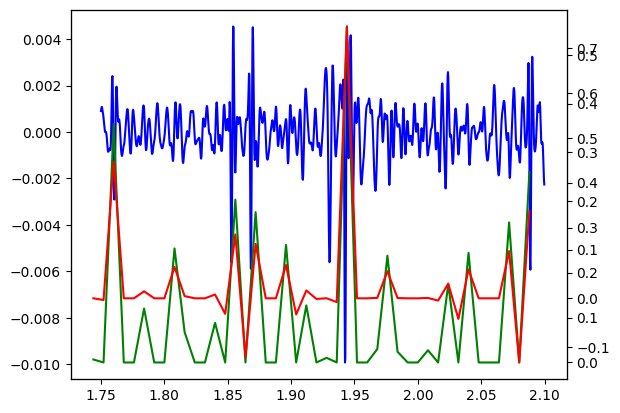

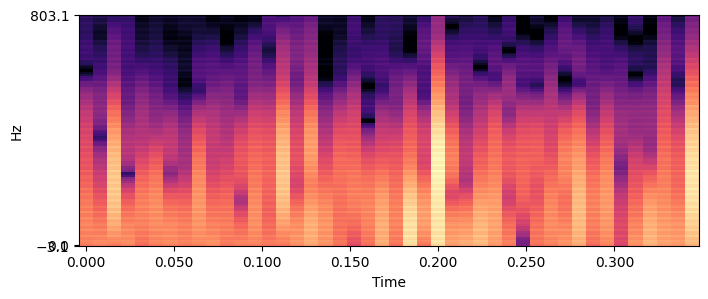

In [85]:
plotStartS = 1.75
plotEndS = 2.1

t_total = len(filt_audio) / sample_rate

fig = plt.figure()

#****** filt_audio

ax = fig.add_subplot(111)
t_filt = np.linspace(0,t_total,len(filt_audio))
startIdx_filt = int((plotStartS / t_total) * len(filt_audio))
endIdx_filt = int((plotEndS / t_total) * len(filt_audio))
ax.plot(t_filt[startIdx_filt:endIdx_filt],filt_audio[startIdx_filt:endIdx_filt],'b')

#****** S1_sum_norm

axNorm = ax.twinx()
t_norm = np.linspace(0,t_total,len(S1_sum_norm))
startIdx_norm = int((plotStartS / t_total) * len(S1_sum_norm))
endIdx_norm = int((plotEndS / t_total) * len(S1_sum_norm))
axNorm.plot(t_norm[startIdx_norm:endIdx_norm],S1_sum_norm[startIdx_norm:endIdx_norm],'g')


#****** S1_tke

axTKE = ax.twinx()
t_TKE = np.linspace(0,t_total,len(S1_tke))
startIdx_tke = int((plotStartS / t_total) * len(S1_tke))
endIdx_tke = int((plotEndS / t_total) * len(S1_tke))
axTKE.plot(t_TKE[startIdx_tke:endIdx_tke],S1_tke[startIdx_tke:endIdx_tke],'r')

#****** Spectrogram

fig2, axSpec = plt.subplots()
fig2.set_size_inches(8,3)

img = librosa.display.specshow(S1[:,startIdx_norm:endIdx_norm], x_axis='time',
                            y_axis='mel', sr=sample_rate, hop_length = 32,
                            fmax=800, ax=axSpec)
plt.show()
